In [ ]:
import matplotlib.pyplot as plt
import math
import numpy as np
import cvxpy as cp
from scipy.integrate import solve_ivp
from scipy import signal
import copy
import os

# Local Packages
from control_utils.politopic_representation import *
from control_utils import levants

rng = np.random.default_rng()

In [2]:
# simulation time
time = 20
eta = 1
eps = 1e-9
x0 = np.array([0.5, 0.88, -0.25, 1, 0, 0, 0, 0])
x0_levants = np.zeros(15)

x0 = np.concat([x0, x0_levants], axis=0)

# normal cases
z_interval = [
    [0.2, 1],
    [.1667, 0.5],
    [-1, 1],
    [-4*math.pi, 4*math.pi]
]
zeta_interval = [
    [-2*math.pi, 2*math.pi]
]

# hyperplanes
a = np.array([
    [1, -1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, -1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, -1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, -1],
])
b = 4*math.pi * np.ones(shape=(4*2, 1)) # limits of set D
bR = b/2.0 # limits of set R

In [ ]:
n_z = len(z_interval)
n_zeta = len(zeta_interval)

interval_size = 2 # Just to make this information explict

j_perms, _ = permn(np.arange(interval_size), n_z)
k_perms, _ = permn(np.arange(interval_size), n_z)
l_perms, _ = permn(np.arange(interval_size), n_zeta)

In [4]:
### This functions must be changed for different systems
# Politopic representation
def A_ijl(z: list[np.ndarray], zeta: list[np.ndarray], **kwargs) -> np.ndarray:
    return np.array([
        [0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 1, 0, 1 + z[0]],
        [0, 2*z[1]*z[2]*z[3], 0, 2*z[1]*z[2]*zeta[0]],
    ])

def C_ijl(z: list[np.ndarray], zeta: list[np.ndarray], **kwargs) -> np.ndarray:
    return np.array([
        [1, 0, 0, 0],
        [0, 0, 1, 0],
    ])

theta_x1 = lambda x1: 3 + 2*math.sin(x1)

# alpha = [x1, x4_hat]
z_alpha = lambda alpha: np.array([
    [1/theta_x1(alpha[0, 0])],
    [1/(1 + theta_x1(alpha[0, 0]))],
    [math.cos(alpha[0, 0])],
    [alpha[1, 0]]
])

In [5]:
A_cell = []
C_cell = []

# TODO: make this a module
for j_p in j_perms:
    for l_p in l_perms:
        jl_perm = np.concat([j_p, l_p])

        A_ind = bin_perm_to_dec(jl_perm)
        C_ind = A_ind

        z = []
        for j in range(n_z):
            z.append(z_interval[j][jl_perm[j]])
        
        zeta = []
        for j in range(n_zeta):
            zeta.append(zeta_interval[j][jl_perm[n_z + j]])
        A_cell.append(A_ijl(z, zeta))
        C_cell.append(C_ijl(z, zeta))

In [6]:
j_perms_plus = perm_plus(j_perms)
k_perms_plus = perm_plus(k_perms)

In [ ]:
# TODO: turn this into a module -> i can move this functions to a politopic representation utils file

# w0_alpha = lambda j, z: ((z_interval[j][1] - z[j]) / (z_interval[j][1] - z_interval[j][0]))
# w1_alpha = lambda j, z: 1 - w0_alpha(j, z)

# w_alpha = lambda j, z: [w0_alpha(j, z), w1_alpha(j, z)]

# def W_ind(z: np.ndarray[float], J_perm_i) -> float: #TODO: put this in the same as the variables z
#     '''
#         alpha = [alpha_1, ..., alpha_N}], alpha_1 = [alpha_11, ..., alpha_1{n_{alpha_1}}]` \\
#         perm = multiindex permutations \\
#         n_prods = number of products
#     '''
    
#     prod = 1
#     for k in range(len(z)): # n_alpha_i
#         prod *= w_alpha(k, z)[J_perm_i[k]]
    
#     return prod

def phi_z(F: np.ndarray, z: np.ndarray, b: np.ndarray): # TODO: move to a local utils under project UIO or to the LMIS definition
    '''
        ### The parameters are given from the expressions and are used to generate Lmis for Theorem 1 of Coutinho et al.
        R = { x \in RR^n : F@x <= b} \\
        phi(z) = min{ b.T@w: F.T@w = z, w \in RR^f >= 0 }
    '''

    w = cp.Variable((b.shape[0], 1))
    constrains = []

    constrains += [ w >= 0]
    
    constrains += [ F.T@w == z ]

    prob = cp.Problem(cp.Minimize(b.T@w), constraints=constrains)
    result = prob.solve(solver=cp.MOSEK, verbose=False)

    return result

<>:9: SyntaxWarning: invalid escape sequence '\i'
<>:9: SyntaxWarning: invalid escape sequence '\i'
C:\Users\luiza\AppData\Local\Temp\ipykernel_17232\35122824.py:9: SyntaxWarning: invalid escape sequence '\i'
  '''


In [8]:
### LMIS

nx = A_cell[0].shape[0]
ny = C_cell[0].shape[0]

P = cp.Variable((nx, nx), symmetric=True)

L_till_cell = []
for perm in k_perms:
    L_till = cp.Variable((nx, ny))
    L_till_cell.append(L_till)

constrains = []
constrains += [P >> eps]

# fixing upsilon
for l in l_perms:

    for m_index in j_perms_plus:
        for n_index in k_perms_plus:

            m_perms = multi_index_permutation(copy.deepcopy(m_index))
            n_perms = multi_index_permutation(copy.deepcopy(n_index))

            Upsilon_mnk_sum = 0
            for m_perm in m_perms:
                for n_perm in n_perms:
                    jl_perm = np.concat([m_perm, l])
                    
                    A_ind = bin_perm_to_dec(copy.deepcopy(jl_perm))
                    L_ind = bin_perm_to_dec(copy.deepcopy(n_perm))
                    C_ind = A_ind

                    M = P@A_cell[A_ind] - L_till_cell[L_ind]@C_cell[C_ind] + eta*P
                    Upsilon_mnk_sum += M + M.T
        
            constrains += [Upsilon_mnk_sum << -eps]

for j in range(a.T.shape[0]):
    # a.T@x <= b
    aj = np.expand_dims(a.T[j], axis=1)
    phi = phi_z(a.T, aj, bR)
    sj = 1/(b[j] - phi) * aj

    M = cp.bmat([
        [np.eye(1), sj.T],
        [sj       , P],
    ])
    constrains += [ M >> 0 ]

prob = cp.Problem(cp.Minimize(cp.trace(P)), constraints=constrains)
result = prob.solve(solver=cp.MOSEK, verbose=True)

                                     CVXPY                                     
                                     v1.6.0                                    
(CVXPY) Feb 22 05:42:46 PM: Your problem has 144 variables, 1016 constraints, and 0 parameters.
(CVXPY) Feb 22 05:42:46 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 22 05:42:46 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 22 05:42:46 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 22 05:42:46 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 22 05:42:46 PM: Compiling problem (target solver=MOSEK).

In [9]:
is_positive_defined = 'positive definite' if all(np.linalg.eig(P.value).eigenvalues > 0) else 'NOT positive defined'
print(f'P = \n{P.value}')
print(f"The solution is \'{prob.status}\', with Trace(P) = {result:.2f} and P is {is_positive_defined}")

P = 
[[ 0.74195243 -0.31496675  0.07449103  0.00800155]
 [-0.31496675  0.16313982 -0.11635984  0.00434741]
 [ 0.07449103 -0.11635984  1.7623263  -0.17049243]
 [ 0.00800155  0.00434741 -0.17049243  0.04214824]]
The solution is 'optimal', with Trace(P) = 2.71 and P is positive definite


In [10]:
L_cell = []

P_inv = np.linalg.inv(P.value)

for k in k_perms:
    L_ind = bin_perm_to_dec(copy.deepcopy(k))
    L_cell.append(P_inv@(L_till_cell[L_ind]).value)

In [11]:
# System specific functions

def f_x(x):
    return np.array([
        [x[1, 0]],
        [-x[1, 0]*theta_x1(x[0, 0]) - x[3, 0]],
        [x[3, 0]],  
        [-x[2, 0]],
    ]).reshape(4, 1)

def g_x(x: np.ndarray) -> np.ndarray[float]:
    return np.array([
        [0, 0],
        [theta_x1(x[0, 0]), 0],
        [1, 0],
        [0, 1],
    ])

def d_x(t: float) -> np.ndarray[float]:
    return np.array([
        [.5*signal.sawtooth(4*math.pi*0.0795774*t, width=0)],
        [signal.square(2*np.pi*0.0795774*t + math.pi)]
    ]).reshape(2, 1)

def h_x(x):
    return np.array([
        [x[0]],
        [x[2]],
    ]).reshape(2, 1)

def Gamma_inv(x):
    return np.array([
        [1/theta_x1(x[0, 0]), 0],
        [0, 1/-(1 + theta_x1(x[0, 0]))]
    ])

def Q_x(x: np.ndarray):
    return np.array([
        [0, 0],
        [1, 0],
        [1/theta_x1(x[0, 0]), 0],
        [0, -1/(1 + theta_x1(x[0, 0]))],
    ])

def Psi_x(x):
    return np.array([
        [-x[1, 0]*theta_x1(x[0, 0]) - x[3, 0]],
        [(1 + theta_x1(x[0, 0]))*x[2, 0] - 2*math.cos(x[0, 0])*x[1, 0]*x[3, 0]],
    ]).reshape(2, 1)

def dot_Y_levants(y: np.ndarray[float], Y_levants: np.ndarray[float]) -> np.ndarray[float]:
    # returns the \dot{Y}_levants

    # Prof. Coutinho gains -> lambda=0.5*[28;25;20;15;10];
    lambda_y1     = 0.5*np.array([28, 25, 20, 15, 10])
    lambda_y2     = 0.5*np.array([28, 25, 20, 15, 10])
    lambda_y2till = 0.5*np.array([28, 25, 20, 15, 10])

    n_y1     = lambda_y1.shape[0]
    n_y2     = lambda_y2.shape[0]
    n_y2till = lambda_y2till.shape[0]

    id_y1 = 0
    id_y2 = id_y1 + n_y1
    id_y2till = id_y2 + n_y2

    z_y1     = Y_levants[id_y1:n_y1]
    z_y2     = Y_levants[id_y2:id_y2+n_y2]
    z_y2till = Y_levants[id_y2till:id_y2till+n_y2till]

    y1 = y[0]
    y2 = y[1]
    y2till = z_y1[2] + theta_x1(y1)*(z_y1[1] - z_y2[1])

    dot_y1     = levants.differentiator(y1, z_y1, lambda_y1)
    dot_y2     = levants.differentiator(y2, z_y2, lambda_y2)
    dot_y2till = levants.differentiator(y2till, z_y2till, lambda_y2till)

    return np.concat([dot_y1, dot_y2, dot_y2till], axis=0)

# TODO: put this in a separated module
def L_alpha(z: np.ndarray, perms: np.ndarray, L_cell: list[np.ndarray]):
    L = 0

    # W_id_sum = 0
    for i in range(len(perms)):
        # W_id_sum += W_ind(z, perms[i])
        L += W_ind(z, perms[i])*L_cell[i]

    # print(f"w_ind_sum = {W_id_sum}")
    return L

def model(t: float, xx: np.ndarray[float], dist_t: list, dist_d: list, dist_d_hat: list):
    print(f"t={t}s")
   
    nx = 4
    xdot = np.zeros(shape=xx.shape)
    xdot = np.expand_dims(xdot, axis=1)

    # [0:4) -> system states
    # [4:8) -> observer states
    # [8:end] -> levants differentiator
    id_x = 0
    id_x_hat = id_x + nx
    id_Y_levants = id_x_hat + nx

    x = xx[id_x:id_x+nx].reshape(4, 1)
    x_hat = xx[id_x_hat:id_x_hat+nx].reshape(4, 1)
    Y_levants = xx[id_Y_levants:]

    # disturbance related
    g = g_x(x)
    d = d_x(t)
    
    # System simulation
    xdot[id_x:id_x+nx] = f_x(x) + g@d

    # inputs to estimator
    y = h_x(x)
    y_hat = h_x(x_hat)
    alpha = np.array([x[0], x_hat[3]]) # try this
    z = z_alpha(alpha)
    Q = Q_x(x_hat)
    Psi = Psi_x(x_hat)
    
    # levants differentiator output vector
    Y = np.array([
        [Y_levants[2]],
        [Y_levants[11]],
    ]).reshape(2, 1)

    # estimator gain
    L = L_alpha(z, k_perms, L_cell)
    
    # Estimatior simulation
    xdot[id_x_hat:id_x_hat+nx] = f_x(x_hat) + Q@(Y - Psi) + L@(y - y_hat)

    # levants differentiator update
    dot_Y = dot_Y_levants(y, Y_levants)
    xdot[id_Y_levants:] = dot_Y

    # disturbance estimatior
    d_hat = Gamma_inv(x_hat)@(Y - Psi)

    # disturbance value and estimatior storage
    dist_t.append(t)
    dist_d.append(d)
    dist_d_hat.append(d_hat)

    return xdot.flatten()

In [12]:
sim_time = (0, time)
dist_t = []
dist_d = []
dist_d_hat = []

result = solve_ivp(model, sim_time, x0, args=(dist_t, dist_d, dist_d_hat))  # BDF or LSODA
t = result.t

x = result.y

t=0.0s
t=4.3769859609613926e-08s
t=8.753971921922785e-07s
t=1.3130957882884176e-06s
t=3.501588768769114e-06s
t=3.890654187521238e-06s
t=4.376985960961392e-06s
t=4.376985960961392e-06s
t=6.075286909976949e-06s
t=6.9244373844847275e-06s
t=1.117018975702362e-05s
t=1.192499017880831e-05s
t=1.2868490706039177e-05s
t=1.2868490706039177e-05s
t=2.00079206249662e-05s
t=2.3577635584429713e-05s
t=4.142621038174727e-05s
t=4.4599290345714835e-05s
t=4.856564030067429e-05s
t=4.856564030067429e-05s
t=6.958126996974825e-05s
t=8.008908480428524e-05s
t=0.00013262815897697013s
t=0.0001419684388298919s
t=0.0001536437886460441s
t=0.0001536437886460441s
t=0.0002169652588146363s
t=0.0002486259938989324s
t=0.00040692966932041283s
t=0.0004350725449508982s
t=0.000470251139489005s
t=0.000470251139489005s
t=0.000659108815704336s
t=0.0007535376538120016s
t=0.0012256818443503292s
t=0.0013096185893349207s
t=0.0014145395205656603s
t=0.0014145395205656603s
t=0.0019228759296807904s
t=0.002177044134238355s
t=0.0034478851

C:\Users\luiza\AppData\Local\Temp\ipykernel_17232\826731017.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  theta_x1 = lambda x1: 3 + 2*math.sin(x1)



t=0.48776089430838393s
t=0.48862773539721444s
t=0.48862773539721444s
t=0.4901712340535055s
t=0.490942983381651s
t=0.49480173002237865s
t=0.49548772942517466s
t=0.4963452286786697s
t=0.4963452286786697s
t=0.49778487344459843s
t=0.49850469582756285s
t=0.5021038077423847s
t=0.5027436498605753s
t=0.5035434525083134s
t=0.5035434525083134s
t=0.5049091287374112s
t=0.5055919668519602s
t=0.5090061574247046s
t=0.5096131246376369s
t=0.5103718336538023s
t=0.5103718336538023s
t=0.5117718047359714s
t=0.5124717902770559s
t=0.5159717179824785s
t=0.5165939273523315s
t=0.5173716890646476s
t=0.5173716890646476s
t=0.5188745319676781s
t=0.5196259534191934s
t=0.5233830606767695s
t=0.5240509908558942s
t=0.5248859035798s
t=0.5248859035798s
t=0.5264357900980499s
t=0.5272107333571747s
t=0.5310854496527992s
t=0.5317742881053548s
t=0.5326353361710491s
t=0.5326353361710491s
t=0.5341079684962377s
t=0.5348442846588318s
t=0.5385258654718031s
t=0.5391803687274426s
t=0.5399984977969917s
t=0.5399984977969917s
t=0.54136

In [13]:
d1 = []
d2 = []
y2tillor = []
doty2tillor = []
for i in range(len(t)):
    d1.append(d_x(t[i])[0, 0])
    d2.append(d_x(t[i])[1, 0])
    y2tillor.append(-4*x[3, i] - 2*math.sin(x[0, i])*x[3, i])
    doty2tillor.append(x[2, i]*(1 + theta_x1(x[0, i])) - d2[i]*(1 + theta_x1(x[0, i])) - 2*math.cos(x[0, i]*x[1, i]*x[3, i]))

# convergence
# plt.plot(t, x[0], 'b') # x1
# plt.plot(t, x[8], 'r--') # y1 = x1
# plt.plot(t, x[1], 'm') # x2
# plt.plot(t, x[9], 'm--') # doty1 = x2
# plt.plot(t, x[10], 'g--') #2doty1

# plt.plot(t, x[2], 'k') # x3
# plt.plot(t, x[13], 'k--') # y2 = x3
# plt.plot(t, x[3] + d1, 'b') # x4 = d1
# plt.plot(t, x[14], 'b--') # doty2 = x3 + d1

# plt.plot(t, y2tillor, 'r') # y2till ori = x3*(1 + theta(x1)) -d2(1 + theta(x1)) - 2cos(x1)x2x4
# plt.plot(t, x[18], 'r--') # y2till
# plt.plot(t, doty2tillor, 'm') # doty2till ori = x3*(1 + theta(x1)) -d2(1 + theta(x1)) - 2cos(x1)x2x4
# plt.plot(t, x[19], 'm--') # doty2till

# plt.ylim([-1, 1])
plt.show()

In [14]:
dist_tt = []
dist_dd = []
dist_dd_hat = []
for i in range(len(dist_t)-1):
    if dist_t[i] < dist_t[i + 1]:
        dist_tt.append(dist_t[i])
        dist_dd.append(dist_d[i])
        dist_dd_hat.append(dist_d_hat[i])

In [15]:
dist_t = np.array(dist_tt)
dist_d = np.array(dist_dd)
dist_d_hat = np.array(dist_dd_hat)

<>:13: SyntaxWarning: invalid escape sequence '\h'
<>:13: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luiza\AppData\Local\Temp\ipykernel_17232\3742911147.py:13: SyntaxWarning: invalid escape sequence '\h'
  axs[i].plot(dist_t, dist_d_hat[:, i], 'r--', label=f'$\hat{{d}}_{i+1}$', linewidth=2)


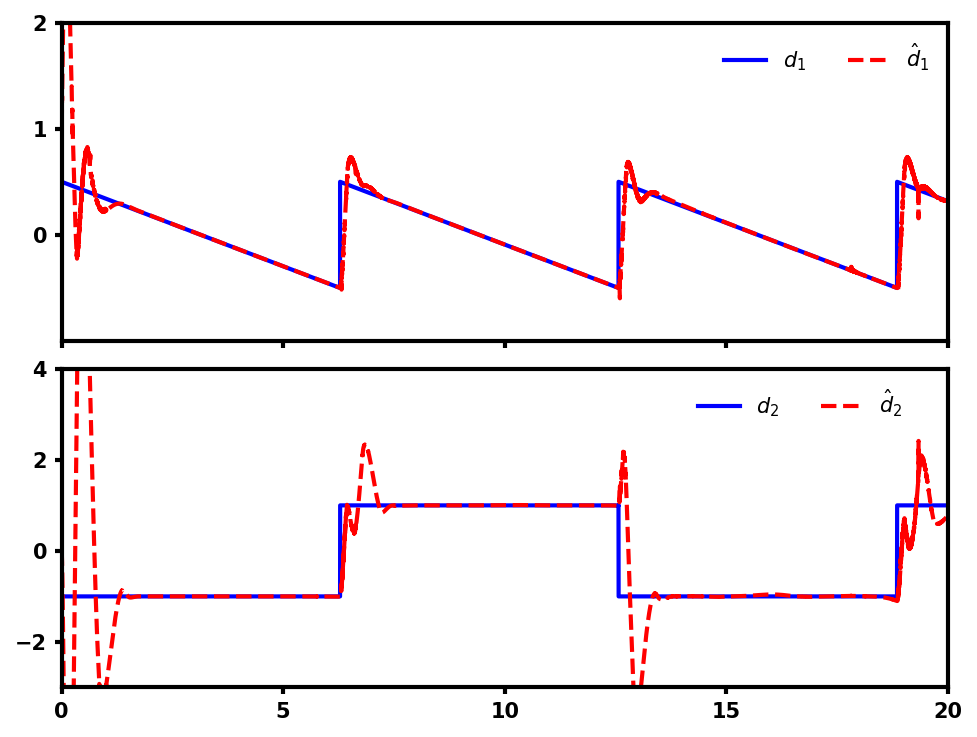

In [16]:
def plot_uios(dist_t, dist_d, dist_d_hat):

    fig, axs = plt.subplots(2, sharex=True, dpi=150, constrained_layout=True)

    ylims = [
        [-1, 2],
        [-3, 4],
    ]

    for i in range(len(axs)):

        axs[i].plot(dist_t, dist_d[:, i], 'b', label=f'$d_{i+1}$', linewidth=2)
        axs[i].plot(dist_t, dist_d_hat[:, i], 'r--', label=f'$\hat{{d}}_{i+1}$', linewidth=2)
        axs[i].set_ylim(ylims[i])
        axs[i].legend(ncols=2, frameon=False, loc='upper right', bbox_to_anchor=(1, 1))
        
        axs[i].set_xticks(np.linspace(0, 20, 5))
        
        if i == 0:
            axs[i].set_yticks([0, 1, 2])
        elif i == 1:
            axs[i].set_yticks([-2, 0, 2, 4])
            axs[i].legend(ncols=2, frameon=False, loc='upper right', bbox_to_anchor=(.97, 1))

        for tick in axs[i].get_xticklabels():
            tick.set_fontweight('bold')
        for tick in axs[i].get_yticklabels():
            tick.set_fontweight('bold')
        for spine in axs[i].spines.values():
            spine.set_linewidth(2)  # Change the value as needed
        axs[i].tick_params(axis='both', width=2)  # Adjust width and length
        
    plt.xlim([0, time])

    dir = os.path.join(os.curdir, f'.figures/')
    if not os.path.isdir(dir):
        os.mkdir(dir)

    plt.savefig(f".figures/disturbances.png")
    plt.show()

plot_uios(dist_t, dist_d, dist_d_hat)

<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luiza\AppData\Local\Temp\ipykernel_17232\1626737602.py:15: SyntaxWarning: invalid escape sequence '\h'
  axs[i].plot(t, x[4+i], 'r--', label=f'$\hat{{x}}_{i+1}$', linewidth=2)


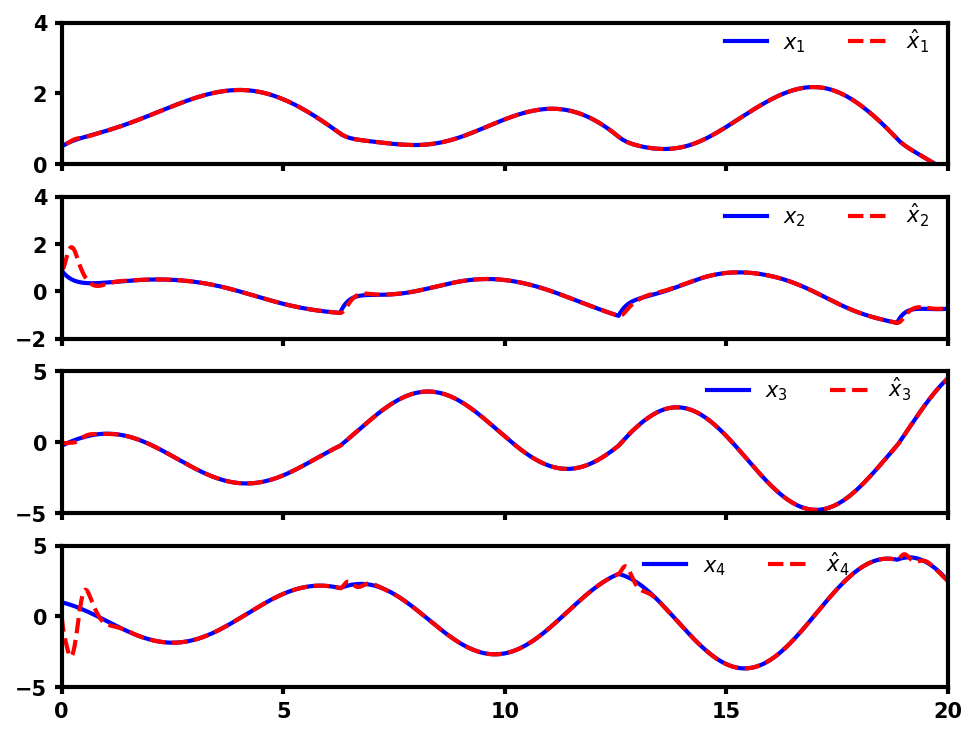

In [17]:
def plot_graph(x, nx):

    fig, axs = plt.subplots(nx, sharex=True, dpi=150, constrained_layout=True)

    ylims = [
        [0, 4],
        [-2, 4],
        [-5, 5],
        [-5, 5]
    ]

    for i in range(len(axs)):

        axs[i].plot(t, x[i], 'b', label=f'$x_{i+1}$', linewidth=2)
        axs[i].plot(t, x[4+i], 'r--', label=f'$\hat{{x}}_{i+1}$', linewidth=2)
        axs[i].set_ylim(ylims[i])
        axs[i].legend(ncols=2, frameon=False, loc='upper right', bbox_to_anchor=(1, 1.1))

        if i == 2:
            axs[i].legend(ncols=2, frameon=False, loc='upper right', bbox_to_anchor=(.98, 1.1))
        elif i == 3:
            axs[i].legend(ncols=2, frameon=False, loc='upper right', bbox_to_anchor=(.91, 1.1))
        
        axs[i].set_xticks(np.linspace(0, 20, 5))

        for tick in axs[i].get_xticklabels():
            tick.set_fontweight('bold')
        for tick in axs[i].get_yticklabels():
            tick.set_fontweight('bold')
        for spine in axs[i].spines.values():
            spine.set_linewidth(2)  # Change the value as needed
        axs[i].tick_params(axis='both', width=2)  # Adjust width and length
        
    plt.xlim([0, time])
    
    plt.savefig(f".figures/states.png")
    plt.show()

plot_graph(x, 4)
    